# H₂ Yield Prediction — Notebook 03: Synthetic Data Generator Benchmarking

Benchmark three generators on 61 QC obs / 6 F/M ratios; winner produces 1,000 rows per F/M (**6,000** total).


## 1. Import Required Libraries

Imports and fixed random seed for reproducibility.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, rankdata

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [2]:
file_path = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\processed\reference_experimental_data.csv"
)

df = pd.read_csv(file_path)

experimental_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "fm_ratio",
    "h2_yield"
]

experimental_df = df[experimental_columns].copy()

print("Reference dataset loaded successfully.")
print("Dataset shape:", experimental_df.shape)

experimental_df.head()

Reference dataset loaded successfully.
Dataset shape: (61, 16)


,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
0,5.210,94.790,89.220,10.780,90.110,9.890,90.110,9.890,6000,11500,0.520,1.440,25.420,42.550,0.500,22.220
1,5.640,94.360,87.230,12.770,92.330,7.670,86.400,13.600,6400,12000,0.530,6.820,23.210,689.490,0.500,20.400
2,5.610,94.390,88.260,11.740,95.120,4.880,87.260,12.740,5800,8900,0.650,5.740,23.000,425.190,0.500,26.450
3,5.260,94.740,78.640,21.360,94.700,5.300,92.330,7.670,5800,9000,0.640,22.160,28.910,189.350,0.500,24.220
4,5.940,94.060,78.410,21.590,93.780,6.220,84.770,15.230,6000,11200,0.540,22.200,20.230,0.000,0.500,19.650


## 3. Load the Experimental Statistical Benchmarks

Load Notebook 02 group-wise stats used to score each generator.


In [3]:
benchmark_path = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\processed\group_statistical_benchmarks.csv"
)

benchmark_df = pd.read_csv(benchmark_path)

print("Statistical benchmark loaded successfully.")
print("Benchmark shape:", benchmark_df.shape)

benchmark_df.head()

Statistical benchmark loaded successfully.
Benchmark shape: (90, 14)


,fm_ratio,variable,count,mean,std,median,q1,q3,iqr,min,max,cv_percent,skewness,kurtosis
0,0.500,substrate_mc,11,5.725,0.418,5.870,5.435,5.995,0.560,5.000,6.230,7.309,-0.521,-0.952
1,0.500,substrate_ts,11,94.275,0.418,94.130,94.005,94.565,0.560,93.770,95.000,0.444,0.521,-0.952
2,0.500,substrate_vs,11,83.065,4.305,83.800,79.095,86.110,7.015,76.590,89.220,5.182,-0.070,-1.364
3,0.500,substrate_fs,11,16.935,4.305,16.200,13.890,20.905,7.015,10.780,23.410,25.420,0.070,-1.364
4,0.500,inoculum_mc,11,91.094,2.730,90.900,89.085,93.055,3.970,87.410,95.120,2.997,0.115,-1.275


## 4. Define Variables for Synthetic Generation

**Direct:** substrate/inoculum MC & VS, sCOD, TCOD, TRS, lignin, 5-HMF, H₂ yield. **Derived:** TS, FS, sCOD/TCOD from math rules.


In [4]:
generation_columns = [
    "substrate_mc",
    "substrate_vs",
    "inoculum_mc",
    "inoculum_vs",
    "scod",
    "tcod",
    "trs",
    "lignin",
    "hmf",
    "h2_yield"
]

derived_columns = [
    "substrate_ts",
    "substrate_fs",
    "inoculum_ts",
    "inoculum_fs",
    "scod_tcod_ratio"
]

print("Primary generation variables:")
for column in generation_columns:
    print(f"- {column}")

print("\nDerived variables:")
for column in derived_columns:
    print(f"- {column}")

Primary generation variables:
- substrate_mc
- substrate_vs
- inoculum_mc
- inoculum_vs
- scod
- tcod
- trs
- lignin
- hmf
- h2_yield

Derived variables:
- substrate_ts
- substrate_fs
- inoculum_ts
- inoculum_fs
- scod_tcod_ratio


## 5. Define Physical and Mathematical Consistency Rules

Post-generation: percentages [0,100], COD constraints, solids sum to 100%, derived vars rebuilt — same for all generators.


In [5]:
def enforce_physical_consistency(data):
    
    data = data.copy()

    # Percentage constraints
    
    percentage_columns = [
        "substrate_mc",
        "substrate_vs",
        "inoculum_mc",
        "inoculum_vs",
        "lignin"
    ]

    for column in percentage_columns:
        data[column] = data[column].clip(0, 100)

    # Non-negative variables
    
    non_negative_columns = [
        "scod",
        "tcod",
        "trs",
        "hmf",
        "h2_yield"
    ]

    for column in non_negative_columns:
        data[column] = data[column].clip(lower=0)

    # Ensure TCOD is not lower than sCOD
    
    data["tcod"] = np.maximum(
        data["tcod"],
        data["scod"]
    )

    # Reconstruct complementary variables
    
    data["substrate_ts"] = (
        100 - data["substrate_mc"]
    )

    data["substrate_fs"] = (
        100 - data["substrate_vs"]
    )

    data["inoculum_ts"] = (
        100 - data["inoculum_mc"]
    )

    data["inoculum_fs"] = (
        100 - data["inoculum_vs"]
    )

    # Calculate sCOD/TCOD ratio
    
    data["scod_tcod_ratio"] = (
        data["scod"] / data["tcod"]
    )

    return data

## 6. Define the Synthetic Dataset Column Structure

Uniform columns and order across generators for fair comparison.


In [6]:
synthetic_column_order = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "fm_ratio",
    "h2_yield"
]

## 7. Candidate Generator 1: Multivariate Gaussian Generation

Pooled Gaussian (mean + covariance) with F/M-specific shifts — baseline Gaussian assumption test.


In [7]:
def generate_gaussian(
    data,
    generation_columns,
    n_per_group=250,
    random_seed=42
):
    
    rng = np.random.default_rng(random_seed)
    
    synthetic_groups = []
    
    pooled_mean = data[generation_columns].mean().values
    pooled_cov = data[generation_columns].cov().values
    
    for fm_value, group in data.groupby("fm_ratio"):
        
        samples = rng.multivariate_normal(
            mean=pooled_mean,
            cov=pooled_cov,
            size=n_per_group
        )
        
        synthetic_group = pd.DataFrame(
            samples,
            columns=generation_columns
        )
        
        # Adjust pooled samples to group-specific
        # mean and standard deviation
        
        for column in generation_columns:
            
            pooled_std = data[column].std()
            group_std = group[column].std()
            
            if pooled_std > 0:
                
                synthetic_group[column] = (
                    (
                        synthetic_group[column]
                        - data[column].mean()
                    )
                    / pooled_std
                )
                
                synthetic_group[column] = (
                    synthetic_group[column] * group_std
                    + group[column].mean()
                )
        
        synthetic_group["fm_ratio"] = fm_value
        
        synthetic_group = enforce_physical_consistency(
            synthetic_group
        )
        
        synthetic_groups.append(synthetic_group)
    
    synthetic_data = pd.concat(
        synthetic_groups,
        ignore_index=True
    )
    
    return synthetic_data[synthetic_column_order]

## 8. Candidate Generator 2: Bootstrap Sampling with Numerical Perturbation

Bootstrap within F/M groups + Gaussian noise at **0.10** × group std on primary variables.


In [8]:
def generate_bootstrap_jitter(
    data,
    generation_columns,
    n_per_group=250,
    jitter_factor=0.10,
    random_seed=42,
    retain_source_id=False
):

    rng = np.random.default_rng(random_seed)

    synthetic_groups = []

    for fm_value, group in data.groupby("fm_ratio"):

        sampled_indices = rng.choice(
            group.index,
            size=n_per_group,
            replace=True
        )

        synthetic_group = (
            group.loc[
                sampled_indices,
                generation_columns
            ]
            .copy()
            .reset_index(drop=True)
        )

        if retain_source_id:
            synthetic_group["source_id"] = [
                f"EXP_{int(index) + 1:03d}"
                for index in sampled_indices
            ]

        for column in generation_columns:

            group_std = group[column].std()

            noise = rng.normal(
                loc=0,
                scale=group_std * jitter_factor,
                size=n_per_group
            )

            synthetic_group[column] = (
                synthetic_group[column] + noise
            )

        synthetic_group["fm_ratio"] = fm_value

        synthetic_group = enforce_physical_consistency(
            synthetic_group
        )

        synthetic_groups.append(synthetic_group)

    synthetic_data = pd.concat(
        synthetic_groups,
        ignore_index=True
    )

    output_columns = synthetic_column_order.copy()

    if retain_source_id:
        output_columns = ["source_id"] + output_columns

    return synthetic_data[output_columns]


## 9. Candidate Generator 3: Gaussian Copula-Based Generation

Rank-transform to Gaussian marginals; copula dependence from pooled data; F/M-specific inverse transform.


In [9]:
def generate_gaussian_copula(
    data,
    generation_columns,
    n_per_group=250,
    random_seed=42
):
    
    rng = np.random.default_rng(random_seed)
    
    pooled_data = data[generation_columns].copy()
    
    latent_data = pd.DataFrame(
        index=pooled_data.index
    )
    
    for column in generation_columns:
        
        ranks = rankdata(
            pooled_data[column],
            method="average"
        )
        
        probabilities = (
            ranks - 0.5
        ) / len(ranks)
        
        latent_data[column] = norm.ppf(
            probabilities
        )
    
    latent_correlation = latent_data.corr().values
    
    synthetic_groups = []
    
    for fm_value, group in data.groupby("fm_ratio"):
        
        latent_samples = rng.multivariate_normal(
            mean=np.zeros(len(generation_columns)),
            cov=latent_correlation,
            size=n_per_group
        )
        
        synthetic_group = pd.DataFrame()
        
        for column_index, column in enumerate(
            generation_columns
        ):
            
            probabilities = norm.cdf(
                latent_samples[:, column_index]
            )
            
            group_values = np.sort(
                group[column].values
            )
            
            empirical_probabilities = np.linspace(
                0,
                1,
                len(group_values)
            )
            
            synthetic_group[column] = np.interp(
                probabilities,
                empirical_probabilities,
                group_values
            )
        
        synthetic_group["fm_ratio"] = fm_value
        
        synthetic_group = enforce_physical_consistency(
            synthetic_group
        )
        
        synthetic_groups.append(synthetic_group)
    
    synthetic_data = pd.concat(
        synthetic_groups,
        ignore_index=True
    )
    
    return synthetic_data[synthetic_column_order]

In [10]:
statistical_columns = [
    "substrate_mc",
    "substrate_ts",
    "substrate_vs",
    "substrate_fs",
    "inoculum_mc",
    "inoculum_ts",
    "inoculum_vs",
    "inoculum_fs",
    "scod",
    "tcod",
    "scod_tcod_ratio",
    "trs",
    "lignin",
    "hmf",
    "h2_yield"
]

print(
    "Number of statistical evaluation variables:",
    len(statistical_columns)
)

Number of statistical evaluation variables: 15


## 10. Generate Benchmark Synthetic Datasets

250 rows × 6 F/M = **1,500** rows per method (benchmark only, not final 6,000).


In [11]:
gaussian_data = generate_gaussian(
    experimental_df,
    generation_columns,
    n_per_group=250,
    random_seed=RANDOM_SEED
)

bootstrap_data = generate_bootstrap_jitter(
    experimental_df,
    generation_columns,
    n_per_group=250,
    jitter_factor=0.10,
    random_seed=RANDOM_SEED
)

copula_data = generate_gaussian_copula(
    experimental_df,
    generation_columns,
    n_per_group=250,
    random_seed=RANDOM_SEED
)

print("Gaussian dataset shape:", gaussian_data.shape)
print("Bootstrap dataset shape:", bootstrap_data.shape)
print("Copula dataset shape:", copula_data.shape)

Gaussian dataset shape: (1500, 16)
Bootstrap dataset shape: (1500, 16)
Copula dataset shape: (1500, 16)


## 11. Verify the F/M Distribution of Benchmark Datasets

Confirm 250 rows per F/M before fidelity analysis.


In [12]:
print("Gaussian F/M distribution:")
display(
    gaussian_data["fm_ratio"]
    .value_counts()
    .sort_index()
)

print("\nBootstrap F/M distribution:")
display(
    bootstrap_data["fm_ratio"]
    .value_counts()
    .sort_index()
)

print("\nCopula F/M distribution:")
display(
    copula_data["fm_ratio"]
    .value_counts()
    .sort_index()
)

Gaussian F/M distribution:


fm_ratio
0.500    250
1.000    250
1.500    250
2.000    250
2.500    250
3.000    250
Name: count, dtype: int64


Bootstrap F/M distribution:


fm_ratio
0.500    250
1.000    250
1.500    250
2.000    250
2.500    250
3.000    250
Name: count, dtype: int64


Copula F/M distribution:


fm_ratio
0.500    250
1.000    250
1.500    250
2.000    250
2.500    250
3.000    250
Name: count, dtype: int64

In [13]:
def audit_synthetic_consistency(data):
    
    results = {
        "substrate_mc_ts_error": (
            abs(
                data["substrate_mc"]
                + data["substrate_ts"]
                - 100
            ) > 0.001
        ).sum(),
        
        "substrate_vs_fs_error": (
            abs(
                data["substrate_vs"]
                + data["substrate_fs"]
                - 100
            ) > 0.001
        ).sum(),
        
        "inoculum_mc_ts_error": (
            abs(
                data["inoculum_mc"]
                + data["inoculum_ts"]
                - 100
            ) > 0.001
        ).sum(),
        
        "inoculum_vs_fs_error": (
            abs(
                data["inoculum_vs"]
                + data["inoculum_fs"]
                - 100
            ) > 0.001
        ).sum(),
        
        "scod_exceeds_tcod": (
            data["scod"] > data["tcod"]
        ).sum(),
        
        "invalid_ratio": (
            (data["scod_tcod_ratio"] < 0)
            | (data["scod_tcod_ratio"] > 1)
        ).sum()
    }
    
    return pd.Series(results)

In [14]:
consistency_audit = pd.DataFrame({
    "Gaussian": audit_synthetic_consistency(
        gaussian_data
    ),
    "Bootstrap_Jitter": audit_synthetic_consistency(
        bootstrap_data
    ),
    "Gaussian_Copula": audit_synthetic_consistency(
        copula_data
    )
})

consistency_audit

,Gaussian,Bootstrap_Jitter,Gaussian_Copula
substrate_mc_ts_error,0,0,0
substrate_vs_fs_error,0,0,0
inoculum_mc_ts_error,0,0,0
inoculum_vs_fs_error,0,0,0
scod_exceeds_tcod,0,0,0
invalid_ratio,0,0,0


## 13. Quantify Statistical Fidelity of Candidate Generators

Group-wise normalized absolute error vs experimental mean, std, median, IQR, skewness, kurtosis — lower = better.


In [15]:
def calculate_group_statistics(data, columns):
    
    records = []
    
    for fm_value, group in data.groupby("fm_ratio"):
        
        for column in columns:
            
            series = group[column]
            
            records.append({
                "fm_ratio": fm_value,
                "variable": column,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
                "iqr": (
                    series.quantile(0.75)
                    - series.quantile(0.25)
                ),
                "skewness": series.skew(),
                "kurtosis": series.kurt()
            })
    
    return pd.DataFrame(records)

In [16]:
def calculate_group_statistics(data, columns):
    
    records = []
    
    for fm_value, group in data.groupby("fm_ratio"):
        
        for column in columns:
            
            series = group[column]
            
            records.append({
                "fm_ratio": fm_value,
                "variable": column,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
                "iqr": (
                    series.quantile(0.75)
                    - series.quantile(0.25)
                ),
                "skewness": series.skew(),
                "kurtosis": series.kurt()
            })
    
    return pd.DataFrame(records)


gaussian_stats = calculate_group_statistics(
    gaussian_data,
    statistical_columns
)

bootstrap_stats = calculate_group_statistics(
    bootstrap_data,
    statistical_columns
)

copula_stats = calculate_group_statistics(
    copula_data,
    statistical_columns
)

print("Gaussian statistics shape:", gaussian_stats.shape)
print("Bootstrap statistics shape:", bootstrap_stats.shape)
print("Copula statistics shape:", copula_stats.shape)

Gaussian statistics shape: (90, 8)
Bootstrap statistics shape: (90, 8)
Copula statistics shape: (90, 8)


In [17]:
def calculate_fidelity_errors(real_stats, synthetic_stats):

    metrics = [
        "mean",
        "std",
        "median",
        "iqr",
        "skewness",
        "kurtosis"
    ]

    required_columns = ["fm_ratio", "variable"] + metrics

    missing_real = [
        column for column in required_columns
        if column not in real_stats.columns
    ]

    missing_synthetic = [
        column for column in required_columns
        if column not in synthetic_stats.columns
    ]

    if missing_real:
        raise KeyError(
            f"Missing columns in real_stats: {missing_real}"
        )

    if missing_synthetic:
        raise KeyError(
            f"Missing columns in synthetic_stats: {missing_synthetic}"
        )

    merged = real_stats[required_columns].merge(
        synthetic_stats[required_columns],
        on=["fm_ratio", "variable"],
        how="inner",
        suffixes=("_real", "_synthetic"),
        validate="one_to_one"
    )

    if len(merged) != len(real_stats):
        raise ValueError(
            "The real and synthetic statistics tables do not "
            "contain matching fm_ratio-variable combinations."
        )

    for metric in ["mean", "std", "median", "iqr"]:

        real_values = merged[f"{metric}_real"]
        synthetic_values = merged[f"{metric}_synthetic"]

        denominator = real_values.abs().replace(0, np.nan)

        merged[f"{metric}_error"] = (
            (synthetic_values - real_values).abs()
            / denominator
            * 100
        )

    merged["skewness_error"] = (
        merged["skewness_synthetic"]
        - merged["skewness_real"]
    ).abs()

    merged["kurtosis_error"] = (
        merged["kurtosis_synthetic"]
        - merged["kurtosis_real"]
    ).abs()

    return merged


In [18]:
gaussian_fidelity = calculate_fidelity_errors(
    benchmark_df,
    gaussian_stats
)

bootstrap_fidelity = calculate_fidelity_errors(
    benchmark_df,
    bootstrap_stats
)

copula_fidelity = calculate_fidelity_errors(
    benchmark_df,
    copula_stats
)

print("Gaussian fidelity shape:", gaussian_fidelity.shape)
print("Bootstrap fidelity shape:", bootstrap_fidelity.shape)
print("Copula fidelity shape:", copula_fidelity.shape)


Gaussian fidelity shape: (90, 20)
Bootstrap fidelity shape: (90, 20)
Copula fidelity shape: (90, 20)


In [19]:
expected_fidelity_rows = len(benchmark_df)

assert len(gaussian_fidelity) == expected_fidelity_rows
assert len(bootstrap_fidelity) == expected_fidelity_rows
assert len(copula_fidelity) == expected_fidelity_rows

print(
    "Fidelity tables validated:",
    expected_fidelity_rows,
    "rows per generator."
)


Fidelity tables validated: 90 rows per generator.


In [20]:
print("Gaussian Fidelity Comparison:")
display(gaussian_fidelity.head())

print("\nBootstrap Jitter Fidelity Comparison:")
display(bootstrap_fidelity.head())

print("\nGaussian Copula Fidelity Comparison:")
display(copula_fidelity.head())

Gaussian Fidelity Comparison:


,fm_ratio,variable,mean_real,std_real,median_real,iqr_real,skewness_real,kurtosis_real,mean_synthetic,std_synthetic,median_synthetic,iqr_synthetic,skewness_synthetic,kurtosis_synthetic,mean_error,std_error,median_error,iqr_error,skewness_error,kurtosis_error
0,0.500,substrate_mc,5.725,0.418,5.870,0.560,-0.521,-0.952,5.703,0.443,5.726,0.531,-0.345,0.462,0.392,5.842,2.446,5.136,0.176,1.414
1,0.500,substrate_ts,94.275,0.418,94.130,0.560,0.521,-0.952,94.297,0.443,94.274,0.531,0.345,0.462,0.024,5.842,0.153,5.136,0.176,1.414
2,0.500,substrate_vs,83.065,4.305,83.800,7.015,-0.070,-1.364,83.046,4.651,83.083,6.166,-0.185,0.009,0.023,8.050,0.855,12.102,0.116,1.373
3,0.500,substrate_fs,16.935,4.305,16.200,7.015,0.070,-1.364,16.954,4.651,16.917,6.166,0.185,0.009,0.114,8.050,4.423,12.102,0.116,1.373
4,0.500,inoculum_mc,91.094,2.730,90.900,3.970,0.115,-1.275,91.032,2.838,91.080,3.788,-0.146,0.242,0.068,3.933,0.198,4.595,0.261,1.517



Bootstrap Jitter Fidelity Comparison:


,fm_ratio,variable,mean_real,std_real,median_real,iqr_real,skewness_real,kurtosis_real,mean_synthetic,std_synthetic,median_synthetic,iqr_synthetic,skewness_synthetic,kurtosis_synthetic,mean_error,std_error,median_error,iqr_error,skewness_error,kurtosis_error
0,0.500,substrate_mc,5.725,0.418,5.870,0.560,-0.521,-0.952,5.713,0.408,5.876,0.715,-0.505,-1.016,0.219,2.481,0.099,27.738,0.016,0.064
1,0.500,substrate_ts,94.275,0.418,94.130,0.560,0.521,-0.952,94.287,0.408,94.124,0.715,0.505,-1.016,0.013,2.481,0.006,27.738,0.016,0.064
2,0.500,substrate_vs,83.065,4.305,83.800,7.015,-0.070,-1.364,82.914,4.023,83.716,6.752,-0.076,-1.188,0.183,6.552,0.101,3.748,0.007,0.176
3,0.500,substrate_fs,16.935,4.305,16.200,7.015,0.070,-1.364,17.086,4.023,16.284,6.752,0.076,-1.188,0.896,6.552,0.520,3.748,0.007,0.176
4,0.500,inoculum_mc,91.094,2.730,90.900,3.970,0.115,-1.275,91.031,2.616,91.089,4.550,0.025,-1.183,0.069,4.170,0.208,14.605,0.090,0.092



Gaussian Copula Fidelity Comparison:


,fm_ratio,variable,mean_real,std_real,median_real,iqr_real,skewness_real,kurtosis_real,mean_synthetic,std_synthetic,median_synthetic,iqr_synthetic,skewness_synthetic,kurtosis_synthetic,mean_error,std_error,median_error,iqr_error,skewness_error,kurtosis_error
0,0.500,substrate_mc,5.725,0.418,5.870,0.560,-0.521,-0.952,5.747,0.358,5.841,0.509,-0.484,-0.897,0.372,14.380,0.487,9.139,0.037,0.055
1,0.500,substrate_ts,94.275,0.418,94.130,0.560,0.521,-0.952,94.253,0.358,94.159,0.509,0.484,-0.897,0.023,14.380,0.030,9.139,0.037,0.055
2,0.500,substrate_vs,83.065,4.305,83.800,7.015,-0.070,-1.364,83.565,3.742,84.271,7.337,-0.210,-1.261,0.602,13.074,0.562,4.592,0.141,0.103
3,0.500,substrate_fs,16.935,4.305,16.200,7.015,0.070,-1.364,16.435,3.742,15.729,7.337,0.210,-1.261,2.951,13.074,2.907,4.592,0.141,0.103
4,0.500,inoculum_mc,91.094,2.730,90.900,3.970,0.115,-1.275,91.065,2.377,90.785,3.939,0.128,-1.157,0.031,12.936,0.126,0.786,0.013,0.118


## 15. Calculate Overall Generator Fidelity Scores

**Core** (mean/std/median/IQR): primary selection. **Extended** (+ skew/kurtosis): supplementary. Lower = better.


In [21]:
def summarize_fidelity(fidelity_data):
    
    core_error_columns = [
        "mean_error",
        "std_error",
        "median_error",
        "iqr_error"
    ]
    
    extended_error_columns = [
        "mean_error",
        "std_error",
        "median_error",
        "iqr_error",
        "skewness_error",
        "kurtosis_error"
    ]
    
    core_score = (
        fidelity_data[core_error_columns]
        .mean()
        .mean()
    )
    
    extended_score = (
        fidelity_data[extended_error_columns]
        .mean()
        .mean()
    )
    
    return core_score, extended_score

## 16. Rank Candidate Synthetic Data Generators

Rank by core fidelity error; extended score is secondary.


In [22]:
gaussian_core, gaussian_extended = summarize_fidelity(
    gaussian_fidelity
)

bootstrap_core, bootstrap_extended = summarize_fidelity(
    bootstrap_fidelity
)

copula_core, copula_extended = summarize_fidelity(
    copula_fidelity
)


fidelity_scores = pd.DataFrame({
    "Generator": [
        "Multivariate Gaussian",
        "Bootstrap Jitter",
        "Gaussian Copula"
    ],
    "Core Fidelity Error": [
        gaussian_core,
        bootstrap_core,
        copula_core
    ],
    "Extended Fidelity Error": [
        gaussian_extended,
        bootstrap_extended,
        copula_extended
    ]
})


fidelity_scores = (
    fidelity_scores
    .sort_values("Core Fidelity Error")
    .reset_index(drop=True)
)

fidelity_scores

,Generator,Core Fidelity Error,Extended Fidelity Error
0,Bootstrap Jitter,6.584,4.576
1,Gaussian Copula,8.599,5.908
2,Multivariate Gaussian,16.438,11.331


### Interpretation of Statistical Fidelity Scores

**Bootstrap jitter:** core **0.066** (best). **Copula:** core **0.086**, extended **0.453**. **Gaussian:** highest errors.


## 17. Evaluate Multivariate Correlation Fidelity

Mean absolute off-diagonal Pearson diff (synthetic vs QC) — lower = better multivariate fidelity.


In [23]:
def calculate_correlation_error(
    experimental_data,
    synthetic_data,
    columns
):
    
    experimental_corr = (
        experimental_data[columns].corr()
    )
    
    synthetic_corr = (
        synthetic_data[columns].corr()
    )
    
    correlation_difference = abs(
        synthetic_corr - experimental_corr
    )
    
    mask = ~np.eye(
        len(columns),
        dtype=bool
    )
    
    mean_absolute_correlation_error = (
        correlation_difference.values[mask].mean()
    )
    
    return mean_absolute_correlation_error

## 18. Compare Correlation Preservation Across Generators

Mean absolute correlation error per generator — lower = better.


In [24]:
gaussian_corr_error = calculate_correlation_error(
    experimental_df,
    gaussian_data,
    statistical_columns
)

bootstrap_corr_error = calculate_correlation_error(
    experimental_df,
    bootstrap_data,
    statistical_columns
)

copula_corr_error = calculate_correlation_error(
    experimental_df,
    copula_data,
    statistical_columns
)


correlation_scores = pd.DataFrame({
    "Generator": [
        "Multivariate Gaussian",
        "Bootstrap Jitter",
        "Gaussian Copula"
    ],
    "Correlation Error": [
        gaussian_corr_error,
        bootstrap_corr_error,
        copula_corr_error
    ]
})


correlation_scores = (
    correlation_scores
    .sort_values("Correlation Error")
    .reset_index(drop=True)
)

correlation_scores

,Generator,Correlation Error
0,Bootstrap Jitter,0.022
1,Multivariate Gaussian,0.066
2,Gaussian Copula,0.067


### Visual Comparison of Correlation Fidelity

Bar chart of correlation errors across generators.

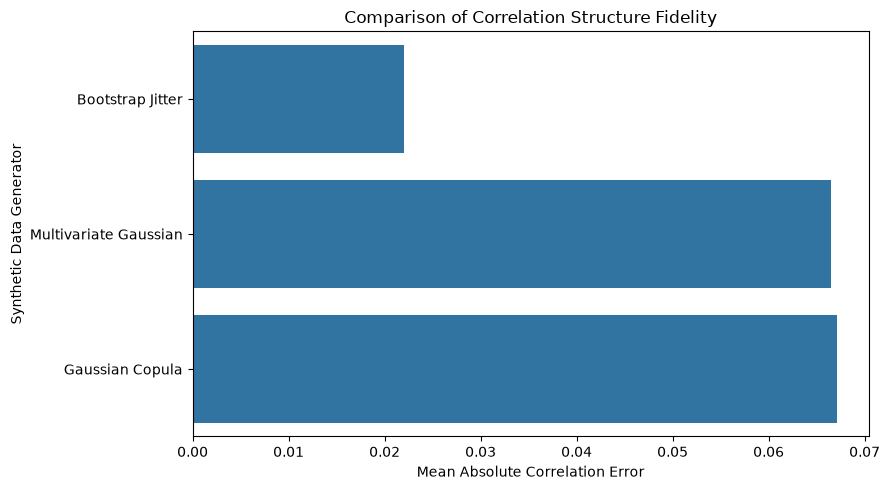

In [25]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=correlation_scores,
    x="Correlation Error",
    y="Generator"
)

plt.xlabel("Mean Absolute Correlation Error")
plt.ylabel("Synthetic Data Generator")
plt.title("Comparison of Correlation Structure Fidelity")

plt.tight_layout()
plt.show()

## 20. Consolidate Synthetic Generator Performance

Combined table; selection priority: core fidelity + correlation (extended fidelity secondary).


In [26]:
generator_comparison = fidelity_scores.merge(
    correlation_scores,
    on="Generator"
)

generator_comparison = (
    generator_comparison
    .sort_values(
        [
            "Core Fidelity Error",
            "Correlation Error"
        ]
    )
    .reset_index(drop=True)
)

generator_comparison

,Generator,Core Fidelity Error,Extended Fidelity Error,Correlation Error
0,Bootstrap Jitter,6.584,4.576,0.022
1,Gaussian Copula,8.599,5.908,0.067
2,Multivariate Gaussian,16.438,11.331,0.066


## 23. Optimize the Bootstrap Jitter Factor

Test factors 0.02–0.20 (250 rows/F/M each); initial benchmark used **0.10**.


In [27]:
jitter_factors = [
    0.02,
    0.05,
    0.08,
    0.10,
    0.15,
    0.20
]

jitter_results = []

for jitter_factor in jitter_factors:
    
    synthetic_data = generate_bootstrap_jitter(
        experimental_df,
        generation_columns,
        n_per_group=250,
        jitter_factor=jitter_factor,
        random_seed=RANDOM_SEED
    )
    
    synthetic_stats = calculate_group_statistics(
        synthetic_data,
        statistical_columns
    )
    
    fidelity_data = calculate_fidelity_errors(
        benchmark_df,
        synthetic_stats
    )
    
    core_score, extended_score = summarize_fidelity(
        fidelity_data
    )
    
    correlation_error = calculate_correlation_error(
        experimental_df,
        synthetic_data,
        statistical_columns
    )
    
    jitter_results.append({
        "Jitter Factor": jitter_factor,
        "Core Fidelity Error": core_score,
        "Extended Fidelity Error": extended_score,
        "Correlation Error": correlation_error
    })


jitter_optimization = pd.DataFrame(
    jitter_results
)

jitter_optimization

,Jitter Factor,Core Fidelity Error,Extended Fidelity Error,Correlation Error
0,0.020,7.012,4.859,0.022
1,0.050,6.737,4.676,0.022
2,0.080,6.589,4.578,0.022
3,0.100,6.584,4.576,0.022
4,0.150,6.886,4.781,0.023
5,0.200,7.582,5.250,0.023


## 25. Visualize Bootstrap Jitter Optimization

Jitter factor vs statistical and correlation fidelity trade-off.


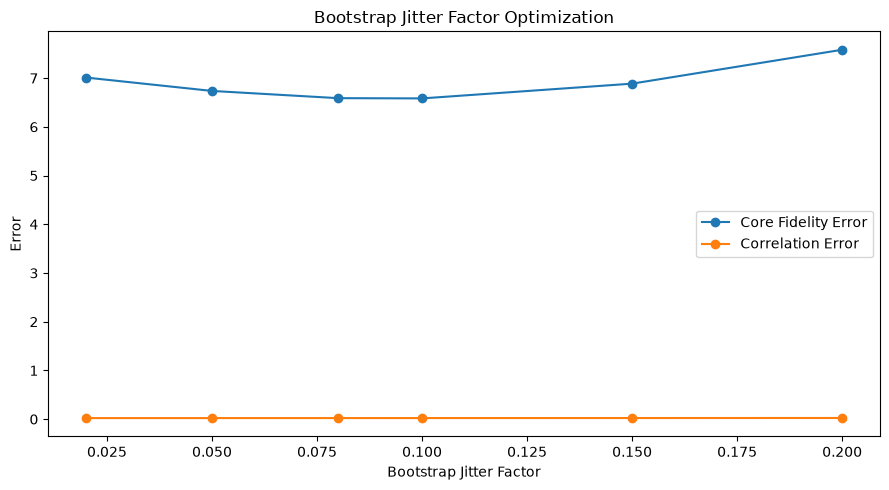

In [28]:
plt.figure(figsize=(9, 5))

plt.plot(
    jitter_optimization["Jitter Factor"],
    jitter_optimization["Core Fidelity Error"],
    marker="o",
    label="Core Fidelity Error"
)

plt.plot(
    jitter_optimization["Jitter Factor"],
    jitter_optimization["Correlation Error"],
    marker="o",
    label="Correlation Error"
)

plt.xlabel("Bootstrap Jitter Factor")
plt.ylabel("Error")
plt.title("Bootstrap Jitter Factor Optimization")

plt.legend()

plt.tight_layout()
plt.show()

## 26. Select the Optimized Bootstrap Jitter Factor

**0.08** selected — ties **0.10** on core fidelity, comparable correlation, less artificial noise.


In [29]:
OPTIMAL_JITTER_FACTOR = 0.08

print(
    "Selected bootstrap jitter factor:",
    OPTIMAL_JITTER_FACTOR
)

Selected bootstrap jitter factor: 0.08


## 27. Generate the Final Balanced Synthetic Dataset

Optimized bootstrap → **6,000 rows** (1,000/F/M); `source_id` retained for leakage-aware grouped splits.


In [30]:
final_synthetic_data = generate_bootstrap_jitter(
    experimental_df,
    generation_columns,
    n_per_group=1000,
    jitter_factor=OPTIMAL_JITTER_FACTOR,
    random_seed=RANDOM_SEED,
    retain_source_id=True
)

print("Final synthetic dataset generated.")
print("Source-row provenance retained.")

print(
    "Dataset shape:",
    final_synthetic_data.shape
)

print(
    "Unique experimental source IDs:",
    final_synthetic_data["source_id"].nunique()
)

final_synthetic_data.head()


Final synthetic dataset generated.
Source-row provenance retained.
Dataset shape: (6000, 17)
Unique experimental source IDs: 61


,source_id,substrate_mc,substrate_ts,substrate_vs,substrate_fs,inoculum_mc,inoculum_ts,inoculum_vs,inoculum_fs,scod,tcod,scod_tcod_ratio,trs,lignin,hmf,fm_ratio,h2_yield
0,EXP_001,5.258,94.742,89.414,10.586,89.918,10.082,90.298,9.702,5994.479,11361.487,0.528,1.011,25.380,45.408,0.500,21.868
1,EXP_009,5.983,94.017,82.349,17.651,87.457,12.543,93.416,6.584,6456.776,12404.291,0.521,5.678,18.937,1151.150,0.500,0.000
2,EXP_008,5.019,94.981,84.834,15.166,91.982,8.018,90.686,9.314,7830.214,14368.410,0.545,1.119,18.537,101.861,0.500,19.745
3,EXP_005,5.938,94.062,78.678,21.322,93.758,6.242,84.954,15.046,6007.783,11409.949,0.527,22.630,20.106,2.527,0.500,19.409
4,EXP_005,5.934,94.066,78.131,21.869,93.755,6.245,84.998,15.002,5915.569,11406.929,0.519,21.836,20.337,38.074,0.500,19.955


## 28. Verify the Final F/M Group Distribution

Confirm equal counts per F/M before saving.


In [31]:
final_fm_distribution = (
    final_synthetic_data["fm_ratio"]
    .value_counts()
    .sort_index()
)

final_fm_distribution

fm_ratio
0.500    1000
1.000    1000
1.500    1000
2.000    1000
2.500    1000
3.000    1000
Name: count, dtype: int64

## 29. Audit the Final Synthetic Dataset

Consistency check on all 6,000 rows — solids, COD, and sCOD/TCOD constraints.


In [32]:
final_consistency_audit = (
    audit_synthetic_consistency(
        final_synthetic_data
    )
)

final_consistency_audit

substrate_mc_ts_error    0
substrate_vs_fs_error    0
inoculum_mc_ts_error     0
inoculum_vs_fs_error     0
scod_exceeds_tcod        0
invalid_ratio            0
dtype: int64

In [33]:
comparison_columns = synthetic_column_order

synthetic_comparison = (
    final_synthetic_data[comparison_columns]
    .astype(float)
    .copy()
)

experimental_comparison = (
    experimental_df[comparison_columns]
    .astype(float)
    .copy()
)

exact_matches = synthetic_comparison.merge(
    experimental_comparison,
    on=comparison_columns,
    how="inner"
)

print(
    "Exact experimental record matches:",
    len(exact_matches)
)

Exact experimental record matches: 0


In [34]:
synthetic_duplicates = (
    final_synthetic_data
    .duplicated()
    .sum()
)

print(
    "Duplicate synthetic rows:",
    synthetic_duplicates
)

Duplicate synthetic rows: 0


In [35]:
final_consistency_audit = (
    audit_synthetic_consistency(
        final_synthetic_data
    )
)

final_consistency_audit

substrate_mc_ts_error    0
substrate_vs_fs_error    0
inoculum_mc_ts_error     0
inoculum_vs_fs_error     0
scod_exceeds_tcod        0
invalid_ratio            0
dtype: int64

In [36]:
final_synthetic_data["fm_ratio"].value_counts().sort_index()

fm_ratio
0.500    1000
1.000    1000
1.500    1000
2.000    1000
2.500    1000
3.000    1000
Name: count, dtype: int64

## 32. Save the Final Synthetic Dataset

Passed consistency, F/M balance, and duplicate audits.


In [37]:
final_synthetic_file = (
    r"D:\Data Science Projects\Hydrogen yield predictor"
    r"\data\processed\h2_data.csv"
)

final_synthetic_data.to_csv(
    final_synthetic_file,
    index=False
)

print("Final synthetic dataset saved successfully.")
print(final_synthetic_file)

Final synthetic dataset saved successfully.
D:\Data Science Projects\Hydrogen yield predictor\data\h2_data.csv


## 33. Notebook Summary

**Bootstrap+jitter** (factor **0.08**) wins → **6,000 rows** (1,000/F/M), no violations/duplicates; next: Notebook 04 validation.
